In [41]:
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import metpy
import project
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os

from wrf import getvar, interplevel
import metpy.calc as mpcalc
from metpy.interpolate import cross_section
from metpy.plots import ctables

In [42]:
file_path = 'wrf_data\index_1\wrfout_d01_2025-07-25_18_00_00.nc'
ncfile = Dataset(file_path)
wrf_ds = xr.open_dataset(file_path)
crs = project.get_projection(wrf_ds)

In [43]:
filename = file_path.split('\\')[-1].split('/')[-1]
parts = filename.split('_')
month_day = parts[2][5:] 
hour = parts[3]           
result = f"{month_day}_{hour}"

In [ ]:
# --- 1. 提取所有必要的 3D 诊断变量 ---
pres = getvar(ncfile, "pressure")      # 全层气压 (hPa)
z = getvar(ncfile, "z", units="dm")    # 全层位势高度 (dm)

reflectivity = getvar(ncfile, "dbz")  # 雷达反射率 (dBZ)
reflectivity_700 = interplevel(reflectivity, pres, 700)  # 700 hPa 的雷达反射率


In [45]:
lon_2d, lat_2d = getvar(ncfile, "lon"), getvar(ncfile, "lat")

In [46]:
print("Reflectivity Max:", reflectivity.max().values)
print("Reflectivity Min:", reflectivity.min().values)


Reflectivity Max: 42.933136
Reflectivity Min: -30.0


Text(<xarray.DataArray 'XLONG' ()>
array(100.90612793)
Coordinates:
    Time     datetime64[ns] 2025-07-25T18:00:00, <xarray.DataArray 'XLAT' ()>
array(25.52036591)
Coordinates:
    Time     datetime64[ns] 2025-07-25T18:00:00, '07-25_18_700hPa_Reflectivity')

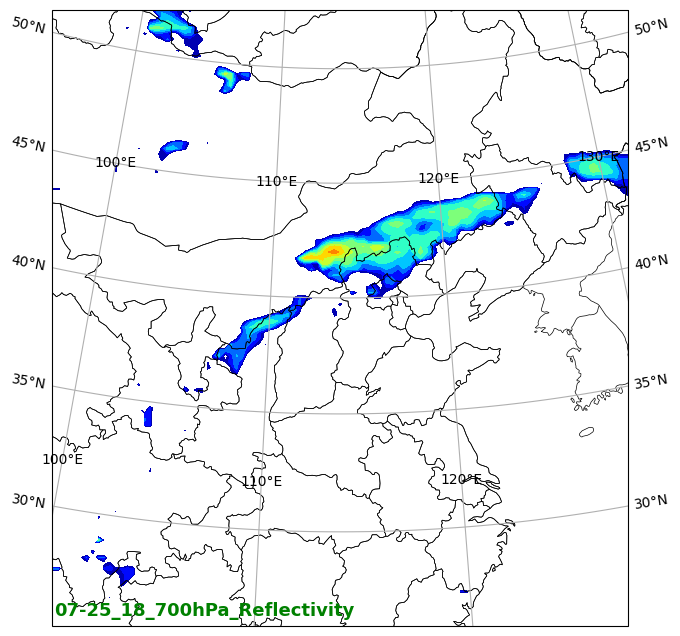

In [54]:
fig,ax = plt.subplots(figsize=(12,8),subplot_kw={'projection':crs},dpi=100)
project.plot_background(lon_2d[0,0],lon_2d[0,-1],lat_2d[0,0],lat_2d[-1,0],ax)

ax.contourf(lon_2d, lat_2d, reflectivity_700, levels=np.arange(0, 60, 5), cmap='jet',transform=ccrs.PlateCarree())
ax.text(lon_2d.min()+7.5, lat_2d.min()+0.2,
            f'{result}_700hPa_Reflectivity', fontsize=13, color='green',
            transform=ccrs.PlateCarree(), weight='bold')